In [11]:
#dit is de code waar het gemakseffect een s-curve heeft.
from mesa import Agent, Model
from mesa.space import MultiGrid
from mesa.time import SimultaneousActivation
from mesa.datacollection import DataCollector
import math
import numpy as np

class Consument(Agent):
    """Een inwoner van Rotterdam met individueel recyclinggedrag."""

    INIT_RECYCLING_PERCENTAGE = 0.5
    GEWICHT_PER_STUK = 0.24          # gemiddeld gewicht kledingstuk in kg
    TEXTIEL_PER_JAAR_KG = 12.1       # totaal afgedankt textiel per persoon per jaar in kg
    AFGEDANKT_PER_JAAR = TEXTIEL_PER_JAAR_KG / GEWICHT_PER_STUK
    AFGEDANKT_PER_MAAND = AFGEDANKT_PER_JAAR / 12

    BELOONING_GROEISNELHEID = 0.8
    BELOONING_MIDDEN = 3.0

    MAX_EFFECT_GEMAK = 0.4
    MAX_TOTAAL_GEMAK_EFFECT = 0.3
    
    BIAS_CORRECTIE = 0.0  # kalibratie voor als dat nodig is

    def advance(self):
        # Voor nu niks extra’s, maar verplicht voor SimultaneousActivation
        pass
    
    def __init__(self, unique_id, model, locatie):
        super().__init__(unique_id, model)
        self.locatie = locatie

        # Individuele eigenschappen
        self.milieubewustzijn = self.random.uniform(0, 1)
        self.prijsgevoeligheid = self.random.uniform(0, 1)
        self.gemaksgevoeligheid = self.random.uniform(0, 1)
        self.sociale_druk_gevoeligheid = self.random.uniform(0, 1)

        # Gedragstoestand
        self.sociale_druk = 0.5
        self.aantal_gerecycled = 0
        self.aantal_weggegooid = 0
        # alleen laatste maand
        self.gerecycled_deze_maand = 0
        self.weggegooid_deze_maand = 0

        self.afgedankt_textiel = self.AFGEDANKT_PER_MAAND
        self.afstand_inzamelpunt = None
        self.afstand_inzamelpunt_basis = None



    
    
    def bepaal_recycling_kans(self):
        """Berekent de kans dat deze agent recycleert op basis van beleid en persoonlijke factoren."""
        basis = self.INIT_RECYCLING_PERCENTAGE
        beloning = self.model.beloning_per_stuk

        # Beloningseffect (aangepast zodat €0 → geen effect)
        if beloning <= 0:
            # Geen beloning → geen effect
            reward_effect = 0
        else:
            # Logistische respons op de hoogte van de beloning
            beloning_factor = 1 / (1 + math.exp(
                -self.BELOONING_GROEISNELHEID * (beloning - self.BELOONING_MIDDEN)
            ))

            # Baseline bij €0 berekenen en weghalen
            baseline = 1 / (1 + math.exp(
                -self.BELOONING_GROEISNELHEID * (0 - self.BELOONING_MIDDEN)
            ))

            # Nu is beloning_factor = 0 bij €0
            beloning_factor -= baseline

            # Geleidelijke opbouw van beleidseffect over de tijd
            # 4 = middenpunt van S-curve (rond maand 6 gaat het echt versnellen)
            # 0.9 laat zien hoe steil de curve is (0.9 = duidelijk zichtbaar)
            beleidsopbouw = 1 / (1 + math.exp(-0.9 * (self.model.huidige_maand - 4)))

            
            reward_effect = self.prijsgevoeligheid * 0.4 * max(0, beloning_factor) * beleidsopbouw



    

    


    
    


        


        
        # Gemakseffect: logistische (S‑vormige) respons op afstand
        if self.afstand_inzamelpunt is not None and self.afstand_inzamelpunt_basis is not None:
            # Logistische scores voor huidige en basisafstand
            # -> dichterbij (kleinere afstand) geeft hogere score (tussen 0 en 1)
            gemak_score = 1 / (1 + math.exp(0.25 * (self.afstand_inzamelpunt - 12)))
            basis_gemak_score = 1 / (1 + math.exp(0.25 * (self.afstand_inzamelpunt_basis - 12)))

            # Verschil in gemak (huidig versus basis)
            delta_gemak = gemak_score - basis_gemak_score

            # Effect verzwaren met gevoeligheid en maximale schaal
            gemak_effect = self.gemaksgevoeligheid * self.MAX_EFFECT_GEMAK * delta_gemak
        else:
            gemak_effect = 0

        # Inperken binnen gewenste grenzen
        gemak_effect_adjusted = max(
            -self.MAX_TOTAAL_GEMAK_EFFECT,
            min(self.MAX_TOTAAL_GEMAK_EFFECT, gemak_effect)
        )

        # Sociale invloed (nabijgelegen buren)
        sociaal_effect = 0.15 * self.sociale_druk_gevoeligheid * (self.sociale_druk - 0.5)

        # milieubewustzijn tussen 0 en 1:
        # onder 0.5 verlaagt recyclingkans, boven 0.5 verhoogt die kans
        milieu_effect = 0.2 * (self.milieubewustzijn - 0.5)

        # Totaaleffecten
        totale_effecten = reward_effect + gemak_effect_adjusted + sociaal_effect + milieu_effect
        return min(1, max(0, basis + totale_effecten - self.BIAS_CORRECTIE))

    def step(self):
        # Neem het gehele aantal stukken zeker mee, en het decimale deel als kans op 1 extra stuk
        """Voert één gedragscyclus uit (één simulatiemaand)."""
        p_recycle = self.bepaal_recycling_kans()
        gerecycled, weggegooid = 0, 0

        hele_stukken = int(self.afgedankt_textiel)
        rest_kans = self.afgedankt_textiel - hele_stukken

        aantal_stukken = hele_stukken
        if self.random.random() < rest_kans:
            aantal_stukken += 1

        for _ in range(aantal_stukken):
            if self.random.random() < p_recycle:
                gerecycled += 1
            else:
                weggegooid += 1
        
        # gedrag van deze maand opslaan
        self.gerecycled_deze_maand = gerecycled
        self.weggegooid_deze_maand = weggegooid

        self.aantal_gerecycled += gerecycled
        self.aantal_weggegooid += weggegooid

class RotterdamModel(Model):
    """Mesa‑model van textielinzameling in Rotterdam (base case)."""

    def __init__(self, grid_size=100, aantal_inzamelpunten=4, maanden=12, seed=None, vaste_inzamelpunten=None, beloning_per_stuk=0):
        super().__init__(seed=seed)
        self.grid = MultiGrid(grid_size, grid_size, torus=False)
        self.schedule = SimultaneousActivation(self)
        self.running = True
        self.maanden = maanden
        self.huidige_maand = 0
        self.beloning_per_stuk = beloning_per_stuk

        # Vaste inzamelpunten genereren voor eerlijke vergelijking
        if vaste_inzamelpunten is None:
            vaste_inzamelpunten = self.genereer_inzamelpunten(8, grid_size)

        self.base_inzamelpunten = vaste_inzamelpunten[:4]
        self.inzamelpunten = vaste_inzamelpunten[:aantal_inzamelpunten]

        # Agenten aanmaken
        agent_id = 0
        for x in range(grid_size):
            for y in range(grid_size):
                agent = Consument(agent_id, self, (x, y))
                self.schedule.add(agent)
                self.grid.place_agent(agent, (x, y))
                agent.afstand_inzamelpunt = self.afstand_tot_dichtstbijzijnde_inzamelpunt((x, y), self.inzamelpunten)
                agent.afstand_inzamelpunt_basis = self.afstand_tot_dichtstbijzijnde_inzamelpunt((x, y), self.base_inzamelpunten)
                agent_id += 1

        # DataCollector (+ /0‑check)

        self.datacollector = DataCollector(
            model_reporters={
                # cumulatief
                "TotaalGerecycled": lambda m: sum(a.aantal_gerecycled for a in m.schedule.agents),
                "TotaalWeggegooid": lambda m: sum(a.aantal_weggegooid for a in m.schedule.agents),
                "RecyclingPercentage": lambda m: (
                    0 if sum(a.aantal_gerecycled + a.aantal_weggegooid for a in m.schedule.agents) == 0
                    else sum(a.aantal_gerecycled for a in m.schedule.agents)
                    / sum(a.aantal_gerecycled + a.aantal_weggegooid for a in m.schedule.agents)
                ),
                # per maand
                "GerecycledDezeMaand": lambda m: sum(a.gerecycled_deze_maand for a in m.schedule.agents),
                "WeggegooidDezeMaand": lambda m: sum(a.weggegooid_deze_maand for a in m.schedule.agents),
                "RecyclingPercentageDezeMaand": lambda m: (
                    0 if sum(a.gerecycled_deze_maand + a.weggegooid_deze_maand for a in m.schedule.agents) == 0
                    else sum(a.gerecycled_deze_maand for a in m.schedule.agents)
                    / sum(a.gerecycled_deze_maand + a.weggegooid_deze_maand for a in m.schedule.agents)
                ),

                "GemiddeldeAfstand": lambda m: np.mean([a.afstand_inzamelpunt for a in m.schedule.agents])
            }
        )
        self.datacollector.collect(self)

    # Gedrags- en interactiefuncties
    def afstand(self, p1, p2):
            """Bereken Euclidische afstand tussen twee punten."""
            return math.hypot(p1[0] - p2[0], p1[1] - p2[1])

    def afstand_tot_dichtstbijzijnde_inzamelpunt(self, agent_loc, punten):
        """Bereken de kortste afstand van een agent tot een inzamelpunt."""
        return min(self.afstand(agent_loc, p) for p in punten)

    def buren_recycling_ratio(self, agent):
        """Bereken het recyclingaandeel van de buren in deze maand."""
        neighbors = self.grid.get_neighbors(agent.pos, moore=True, include_center=False, radius=2)
        if not neighbors:
            return 0.5

        totaal_gerecycled = sum(n.gerecycled_deze_maand for n in neighbors)
        totaal_textiel = sum(
            n.gerecycled_deze_maand + n.weggegooid_deze_maand
            for n in neighbors
        )

        if totaal_textiel == 0:
            return 0.5

        return totaal_gerecycled / totaal_textiel

    def genereer_inzamelpunten(self, aantal, grid_size):
        """Genereer inzamelpunten met minimale afstand tussen elkaar."""
        locaties = []
        min_afstand = grid_size / 5  # bijvoorbeeld: 100 grid → 20 afstand

        while len(locaties) < aantal:
            nieuw_punt = (
                self.random.randint(0, grid_size - 1),
                self.random.randint(0, grid_size - 1)
            )

            #check afstand tot bestaande punten
            te_dichtbij = False
            for bestaand in locaties:
                if self.afstand(nieuw_punt, bestaand) < min_afstand:
                    te_dichtbij = True
                    break

            if not te_dichtbij:
                locaties.append(nieuw_punt)

        return locaties

    # Simulatiestap
    
    def step(self):
        self.huidige_maand += 1
        
        for agent in self.schedule.agents:
            agent.sociale_druk = self.buren_recycling_ratio(agent)
        self.schedule.step()
        self.datacollector.collect(self)

#   SIMULATIE DRAAIEN & RESULTATEN

# ENKELE RUN (debug / controle)
model = RotterdamModel(grid_size=100, aantal_inzamelpunten=4, maanden=12)

for maand in range(model.maanden):
    model.step()

data = model.datacollector.get_model_vars_dataframe()
maanden_labels = [
    "Jan", "Feb", "Mrt", "Apr", "Mei", "Jun",
    "Jul", "Aug", "Sep", "Okt", "Nov", "Dec", "Eind"
]

data = data.iloc[1:]  # eerste rij weg
data.index = maanden_labels[:len(data)]
print(data)
#print(data.tail())


     TotaalGerecycled  TotaalWeggegooid  RecyclingPercentage  \
Jan             20995             21059             0.499239   
Feb             41838             42281             0.497367   
Mrt             62828             63271             0.498243   
Apr             83598             84504             0.497305   
Mei            104457            105635             0.497196   
Jun            125554            126554             0.498017   
Jul            146616            147558             0.498399   
Aug            167612            168562             0.498587   
Sep            188561            189587             0.498643   
Okt            209540            210614             0.498722   
Nov            230464            231652             0.498715   
Dec            251535            252545             0.498998   

     GerecycledDezeMaand  WeggegooidDezeMaand  RecyclingPercentageDezeMaand  \
Jan                20995                21059                      0.499239   
Feb      

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

def run_single_simulation(beloning, maanden=12, grid_size=100, aantal_inzamelpunten=4, seed=1):
    model = RotterdamModel(
        grid_size=grid_size,
        aantal_inzamelpunten=aantal_inzamelpunten,
        maanden=maanden,
        seed=seed,
        beloning_per_stuk=beloning
    )

    for _ in range(maanden):
        model.step()

    data = model.datacollector.get_model_vars_dataframe().iloc[1:].copy()
    data["Maand"] = range(1, len(data) + 1)
    data["Beloning"] = beloning
    return data

   Beloning  EindRecyclingPercentage
0         0                 0.499862
1         1                 0.512611
2         2                 0.534202
3         3                 0.563287
4         4                 0.592145
5         5                 0.613547


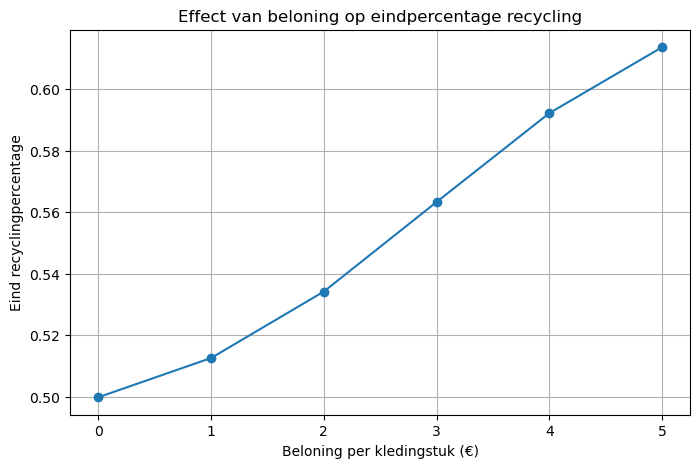

In [15]:
beloningen = [0, 1, 2, 3, 4, 5]
eindresultaten = []

for beloning in beloningen:
    data = run_single_simulation(
        beloning=beloning,
        maanden=12,
        grid_size=100,
        aantal_inzamelpunten=4,
        seed=1
    )

    eindresultaten.append({
        "Beloning": beloning,
        "EindRecyclingPercentage": data["RecyclingPercentage"].iloc[-1]
    })

df_eind = pd.DataFrame(eindresultaten)
print(df_eind)

plt.figure(figsize=(8, 5))
plt.plot(df_eind["Beloning"], df_eind["EindRecyclingPercentage"], marker="o")
plt.xlabel("Beloning per kledingstuk (€)")
plt.ylabel("Eind recyclingpercentage")
plt.title("Effect van beloning op eindpercentage recycling")
plt.grid(True)
plt.show()

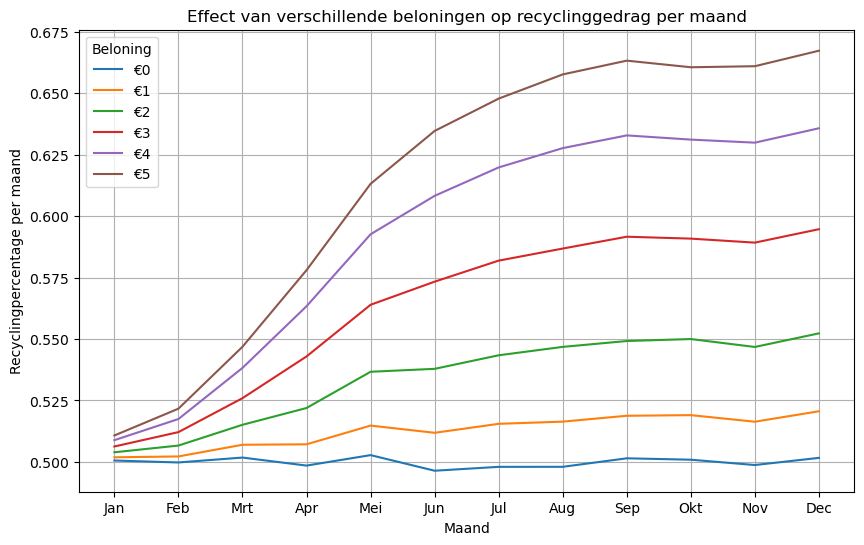

In [17]:
beloningen = [0, 1, 2, 3, 4, 5]
maanden_labels = ["Jan", "Feb", "Mrt", "Apr", "Mei", "Jun",
                  "Jul", "Aug", "Sep", "Okt", "Nov", "Dec"]

plt.figure(figsize=(10, 6))

for beloning in beloningen:
    data = run_single_simulation(
        beloning=beloning,
        maanden=12,
        grid_size=100,
        aantal_inzamelpunten=4,
        seed=1
    )

    plt.plot(
        data["Maand"],
        data["RecyclingPercentageDezeMaand"],
        label=f"€{beloning}"
    )

plt.xlabel("Maand")
plt.ylabel("Recyclingpercentage per maand")
plt.title("Effect van verschillende beloningen op recyclinggedrag per maand")
plt.xticks(range(1, 13), maanden_labels)
plt.legend(title="Beloning")
plt.grid(True)
plt.show()

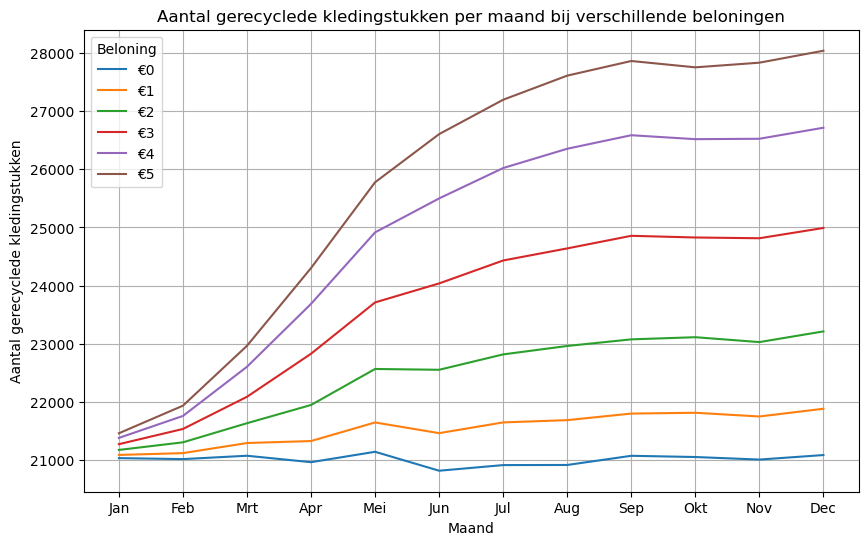

In [19]:
beloningen = [0, 1, 2, 3, 4, 5]
maanden_labels = ["Jan", "Feb", "Mrt", "Apr", "Mei", "Jun",
                  "Jul", "Aug", "Sep", "Okt", "Nov", "Dec"]

plt.figure(figsize=(10, 6))

for beloning in beloningen:
    data = run_single_simulation(
        beloning=beloning,
        maanden=12,
        grid_size=100,
        aantal_inzamelpunten=4,
        seed=1
    )

    plt.plot(
        data["Maand"],
        data["GerecycledDezeMaand"],
        label=f"€{beloning}"
    )

plt.xlabel("Maand")
plt.ylabel("Aantal gerecyclede kledingstukken")
plt.title("Aantal gerecyclede kledingstukken per maand bij verschillende beloningen")
plt.xticks(range(1, 13), maanden_labels)
plt.legend(title="Beloning")
plt.grid(True)
plt.show()

In [21]:
def run_multiple_simulations_for_reward(beloning, n_runs=5, maanden=12, grid_size=100, aantal_inzamelpunten=4):
    alle_runs = []

    for run in range(n_runs):
        model = RotterdamModel(
            grid_size=grid_size,
            aantal_inzamelpunten=aantal_inzamelpunten,
            maanden=maanden,
            seed=run,
            beloning_per_stuk=beloning
        )

        for _ in range(maanden):
            model.step()

        data = model.datacollector.get_model_vars_dataframe().iloc[1:].copy()
        data["Maand"] = range(1, len(data) + 1)
        data["Run"] = run
        data["Beloning"] = beloning
        alle_runs.append(data)

    return pd.concat(alle_runs, ignore_index=True)

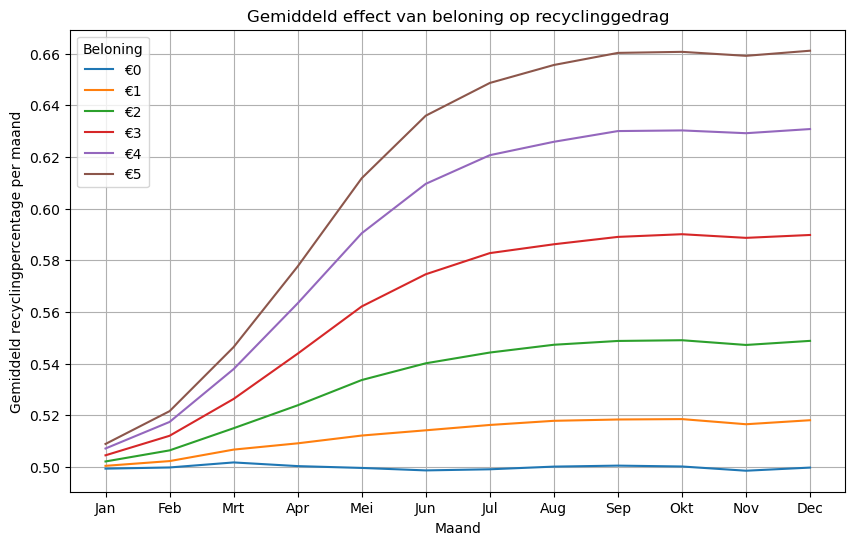

In [23]:
beloningen = [0, 1, 2, 3, 4, 5]
maanden_labels = ["Jan", "Feb", "Mrt", "Apr", "Mei", "Jun",
                  "Jul", "Aug", "Sep", "Okt", "Nov", "Dec"]

plt.figure(figsize=(10, 6))

for beloning in beloningen:
    resultaten = run_multiple_simulations_for_reward(
        beloning=beloning,
        n_runs=5,
        maanden=12,
        grid_size=100,
        aantal_inzamelpunten=4
    )

    gemiddelde = resultaten.groupby("Maand")["RecyclingPercentageDezeMaand"].mean()

    plt.plot(gemiddelde.index, gemiddelde.values, label=f"€{beloning}")

plt.xlabel("Maand")
plt.ylabel("Gemiddeld recyclingpercentage per maand")
plt.title("Gemiddeld effect van beloning op recyclinggedrag")
plt.xticks(range(1, 13), maanden_labels)
plt.legend(title="Beloning")
plt.grid(True)
plt.show()

   Beloning  GemiddeldeEindscore       Std
0         0             0.499826  0.000730
1         1             0.512558  0.000883
2         2             0.533894  0.000864
3         3             0.562511  0.000836
4         4             0.591056  0.000986
5         5             0.612305  0.001010


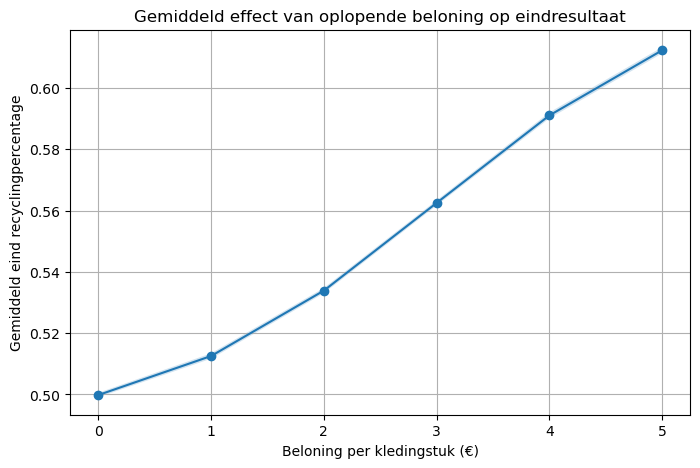

In [24]:
beloningen = [0, 1, 2, 3, 4, 5]
samenvatting = []

for beloning in beloningen:
    resultaten = run_multiple_simulations_for_reward(
        beloning=beloning,
        n_runs=5,
        maanden=12,
        grid_size=100,
        aantal_inzamelpunten=4
    )

    eind_maand = resultaten["Maand"].max()
    eindwaarden = resultaten[resultaten["Maand"] == eind_maand]["RecyclingPercentage"]

    samenvatting.append({
        "Beloning": beloning,
        "GemiddeldeEindscore": eindwaarden.mean(),
        "Std": eindwaarden.std()
    })

df_samenvatting = pd.DataFrame(samenvatting)
print(df_samenvatting)

plt.figure(figsize=(8, 5))
plt.plot(df_samenvatting["Beloning"], df_samenvatting["GemiddeldeEindscore"], marker="o")
plt.fill_between(
    df_samenvatting["Beloning"],
    df_samenvatting["GemiddeldeEindscore"] - df_samenvatting["Std"],
    df_samenvatting["GemiddeldeEindscore"] + df_samenvatting["Std"],
    alpha=0.2
)
plt.xlabel("Beloning per kledingstuk (€)")
plt.ylabel("Gemiddeld eind recyclingpercentage")
plt.title("Gemiddeld effect van oplopende beloning op eindresultaat")
plt.grid(True)
plt.show()

In [45]:
for beloning in [0, 1, 2, 3, 4, 5]:
    model = RotterdamModel(
        grid_size=50,
        aantal_inzamelpunten=4,
        maanden=12,
        seed=1,
        beloning_per_stuk=beloning
    )

    for _ in range(model.maanden):
        model.step()

    data = model.datacollector.get_model_vars_dataframe().iloc[1:]
    eindperc = data["RecyclingPercentage"].iloc[-1]
    print(f"Beloning €{beloning}: {eindperc:.3f}")

Beloning €0: 0.502
Beloning €1: 0.520
Beloning €2: 0.550
Beloning €3: 0.591
Beloning €4: 0.631
Beloning €5: 0.661


In [47]:
# Cel 2 — Één simulatie draaien
# Zet deze cel DIRECT ONDER de modelcode

model = RotterdamModel(grid_size=100, aantal_inzamelpunten=4, maanden=12)

for maand in range(model.maanden):
    model.step()

data = model.datacollector.get_model_vars_dataframe().copy()

# eerste rij is de beginsituatie, die haal je meestal weg voor grafieken
data = data.iloc[1:].copy()

maanden_labels = ["Jan", "Feb", "Mrt", "Apr", "Mei", "Jun",
                  "Jul", "Aug", "Sep", "Okt", "Nov", "Dec"]

data.index = maanden_labels[:len(data)]

print(data)


     TotaalGerecycled  TotaalWeggegooid  RecyclingPercentage  \
Jan             21002             20988             0.500167   
Feb             41747             42291             0.496763   
Mrt             62754             63259             0.497996   
Apr             83802             84186             0.498857   
Mei            105026            104967             0.500140   
Jun            126043            125950             0.500185   
Jul            146900            147051             0.499743   
Aug            167844            168099             0.499620   
Sep            188864            189116             0.499667   
Okt            209905            210111             0.499755   
Nov            230863            231109             0.499734   
Dec            251846            252108             0.499740   

     GerecycledDezeMaand  WeggegooidDezeMaand  RecyclingPercentageDezeMaand  \
Jan                21002                20988                      0.500167   
Feb      

In [117]:
# 30 RUNS (base case kalibratie)
import numpy as np

AANTAL_RUNS = 30
RESULTATEN = []

for run in range(AANTAL_RUNS):
    model = RotterdamModel(grid_size=100, aantal_inzamelpunten=4, maanden=12)

    for maand in range(model.maanden):
        model.step()

    data = model.datacollector.get_model_vars_dataframe()

    # pak laatste waarde (eind van simulatie)
    eind_percentage = data["RecyclingPercentage"].iloc[-1]
    RESULTATEN.append(eind_percentage)

# statistieken berekenen
gemiddelde = np.mean(RESULTATEN)
minimum = np.min(RESULTATEN)
maximum = np.max(RESULTATEN)
std = np.std(RESULTATEN)

print(f"Aantal runs: {AANTAL_RUNS}")
print(f"Gemiddelde recycling: {gemiddelde:.3f}")
print(f"Minimum: {minimum:.3f}")
print(f"Maximum: {maximum:.3f}")
print(f"Standaardafwijking: {std:.3f}")

Aantal runs: 30
Gemiddelde recycling: 0.500
Minimum: 0.497
Maximum: 0.501
Standaardafwijking: 0.001
